## User Notebook - Synthesis with a Reduced Representation

The scattering statistics can be **reduced** before being used as a synthesis target, by exploiting their symmetries:

- `iso=True` averages over absolute orientation, keeping only relative angles.
- `angular_ft=True` with `harmonics_angle=2` keeps the 2 lowest angular harmonics.
- `scale_ft=True` with `harmonics_scale=4` keeps the 4 lowest scale harmonics.
- `dj=3` keeps only scale differences that are at most 3.

This notebook synthesizes a field from such a reduced representation, and compares it to a synthesis from the full set of coefficients and to the true field.

In [1]:
# Library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

import os
import sys

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"

# Force default device
#import STL_main.torch_backend as bk
#bk._DEFAULT_DEVICE = torch.device("cpu")

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.Synthesis import optimize_from_maps
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Working on device: cpu


#### Load the target field

In [2]:
im = np.load(DATA_TEST_PATH + "/" + "Turb_6.npy")[0]  # [Nx, Ny]

# Instantiate kernel data class on the target image
data_target = STL_2D_Kernel_Torch(array=im, pbc=True)

#### Define the ST operators

The same operator is used for the target and the running map, since both are periodic, of identical shape and free of NaNs.

In [3]:
# Full representation
st_op_full = data_target.get_ST_op()

# Reduced representation
st_op_reduced = data_target.get_ST_op(
    iso=True,
    angular_ft=True,
    harmonics_angle=2,
    scale_ft=True,
    harmonics_scale=4,
    dj = 3
)

#### Run the syntheses

The number of optimized coefficients is printed for each representation.

In [4]:
u_full = optimize_from_maps(
    data_target,
    st_op_full,
    st_op_full,
    nbatch=1,
    pbc_running=True,
    compute_PS=True,
    seed=0,
    verbose=True,
)

Running synthesis on device: cpu dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Prefiltering target to remove frequencies above Nyquist
Synthesis on 3986 ST coefficients
Prefiltering initial map to remove frequencies above Nyquist
[LBFGS] iter 10, loss = 1.464910e+03
[LBFGS] iter 20, loss = 2.831439e+01
[LBFGS] iter 30, loss = 8.442236e+00
[LBFGS] iter 40, loss = 3.269870e+00
[LBFGS] iter 50, loss = 1.811454e+00
[LBFGS] iter 60, loss = 1.223007e+00
[LBFGS] iter 70, loss = 9.196415e-01
[LBFGS] iter 80, loss = 7.382172e-01
[LBFGS] iter 90, loss = 6.438708e-01
[LBFGS] iter 100, loss = 5.770085e-01
108 iterations of synthesis.
Execution time: 19.506 s


In [5]:
u_reduced = optimize_from_maps(
    data_target,
    st_op_reduced,
    st_op_reduced,
    nbatch=1,
    pbc_running=True,
    compute_PS=True,
    seed=0,
    verbose=True,
)

Running synthesis on device: cpu dtype: torch.float64
Initial shape for u: (1, 1, 256, 256)
Prefiltering target to remove frequencies above Nyquist
Synthesis on 150 ST coefficients
Prefiltering initial map to remove frequencies above Nyquist
[LBFGS] iter 10, loss = 1.747769e+03
[LBFGS] iter 20, loss = 1.222040e+01
[LBFGS] iter 30, loss = 3.800625e+00
[LBFGS] iter 40, loss = 9.683090e-01
[LBFGS] iter 50, loss = 2.426975e-01
[LBFGS] iter 60, loss = 1.420698e-01
[LBFGS] iter 70, loss = 1.010224e-01
[LBFGS] iter 80, loss = 8.014275e-02
[LBFGS] iter 90, loss = 8.540107e-02
[LBFGS] iter 100, loss = 5.017294e-02
[LBFGS] iter 110, loss = 3.128489e-02
111 iterations of synthesis.
Execution time: 23.290 s


#### Compare the syntheses to the true field

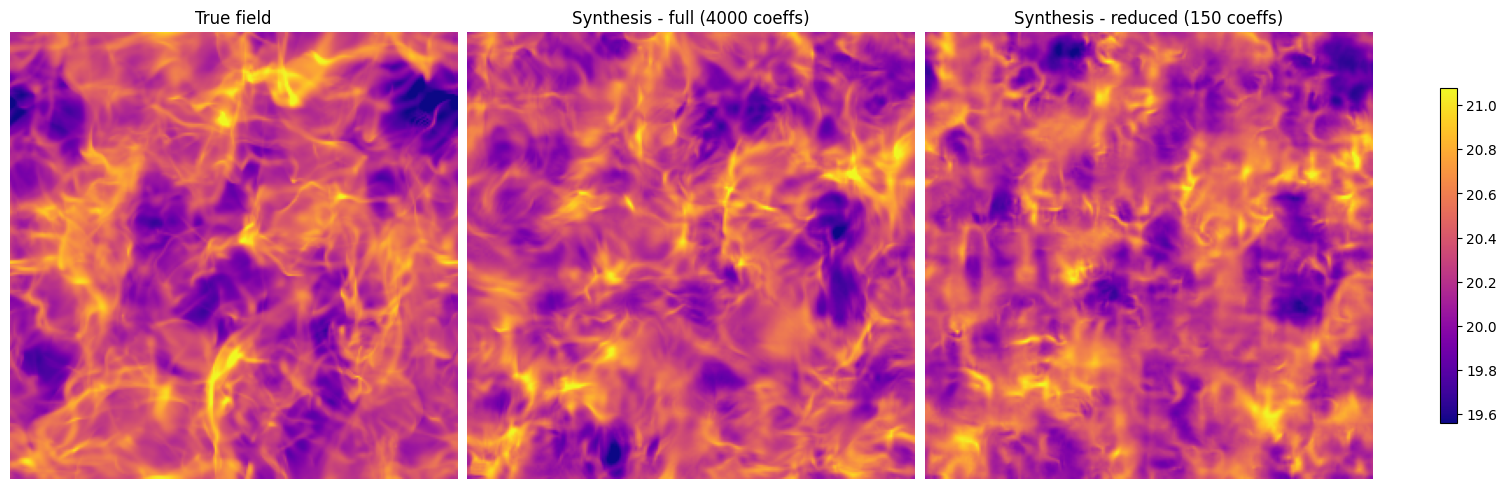

In [6]:
to_numpy = lambda x: x.detach().cpu().numpy()

t = to_numpy(data_target.array)

# Color scale limits of the true field
vmin = np.nanmean(t) - 3 * np.nanstd(t)
vmax = np.nanmean(t) + 3 * np.nanstd(t)

fields = [t, to_numpy(u_full), to_numpy(u_reduced)]
titles = ["True field", "Synthesis - full (4000 coeffs)", "Synthesis - reduced (150 coeffs)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, field, title in zip(axes, fields, titles):
    im_plot = ax.imshow(field, cmap="plasma", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(im_plot, ax=axes, shrink=0.7)

plt.show()